c:\Users\Gawai\.conda\envs\ML\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:05:39] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


📊 分类报告：

              precision    recall  f1-score   support

           0       0.84      0.82      0.83        99
           1       0.85      0.87      0.86       122

    accuracy                           0.85       221
   macro avg       0.84      0.84      0.84       221
weighted avg       0.85      0.85      0.85       221



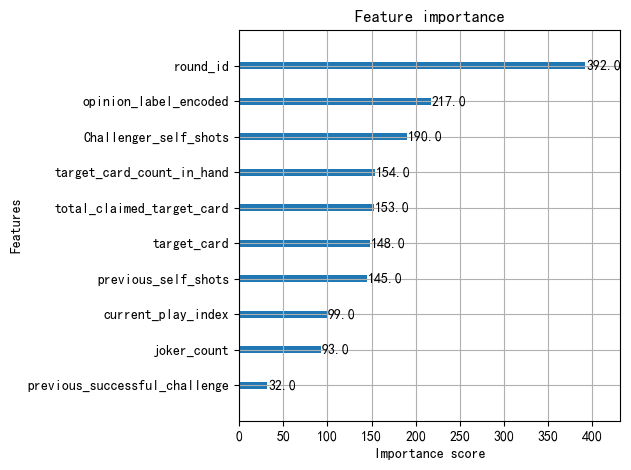

🔍 正在分析每条样本的 LIME 解释: 100%|██████████| 221/221 [00:07<00:00, 30.16it/s]


🔥 前10个平均 LIME 特征重要性：

                                     Feature  Average Importance  Count
21      previous_successful_challenge > 0.00            0.461479     26
32              Challenger_self_shots > 3.00            0.392826     27
10      1.00 < Challenger_self_shots <= 3.00            0.359341     74
2                           round_id <= 2.00            0.181266     54
22      0.00 < Challenger_self_shots <= 1.00            0.140740     54
31          total_claimed_target_card > 3.00            0.092908     37
11  2.00 < total_claimed_target_card <= 3.00            0.075506     31
23                   2.00 < round_id <= 5.00            0.061854     52
29                previous_self_shots > 3.00            0.061557     23
17         target_card_count_in_hand <= 1.00            0.051284    105


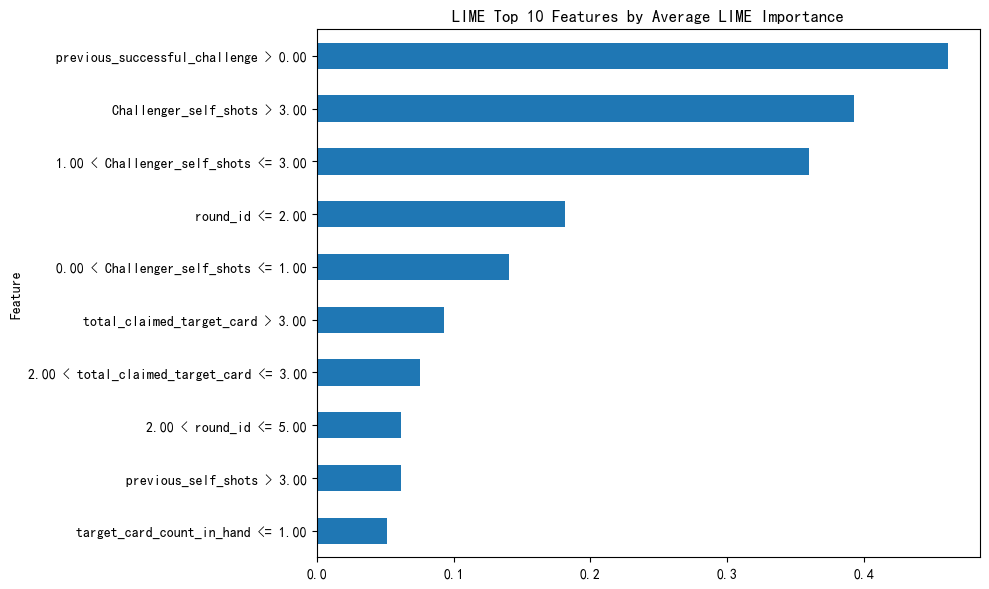

In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from xgboost import plot_importance
from lime.lime_tabular import LimeTabularExplainer
from collections import defaultdict
from tqdm import tqdm

# ========== 1. 读取数据 ==========
csv_path = "C:\\Software\\Code\\merged_output.csv"
df = pd.read_csv(csv_path)

# 删除不需要的列
df = df.drop(columns=[
    "game_id", "player", "challenger", "challenge_result", "opinion_text", "behavior"
], errors="ignore")

# 编码 opinion_label
if "opinion_label" in df.columns:
    opinion_le = LabelEncoder()
    df["opinion_label_encoded"] = opinion_le.fit_transform(df["opinion_label"].astype(str))
else:
    raise ValueError("❌ 数据中未找到 opinion_label 列，请先生成标签。")

# 布尔类型转换
df["was_challenged"] = df["was_challenged"].astype(bool)
df["previous_successful_challenge"] = df["previous_successful_challenge"].astype(bool)

# 设置目标变量
y = df["was_challenged"].astype(int)

# 特征选择
X = df.drop(columns=["was_challenged", "opinion_label"])

# 编码 target_card
if "target_card" in X.columns:
    target_card_le = LabelEncoder()
    X["target_card"] = target_card_le.fit_transform(X["target_card"].astype(str))

# 填充缺失值
X = X.fillna(-1)

# 划分训练集/测试集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=43, stratify=y
)

# ========== 2. 模型训练 ==========
model = XGBClassifier(use_label_encoder=False, eval_metric="logloss")
model.fit(X_train, y_train)

# 模型评估
y_pred = model.predict(X_test)
print("📊 分类报告：\n")
print(classification_report(y_test, y_pred))

# 特征重要性
plot_importance(model)
plt.tight_layout()
plt.show()

# ========== 3. 构建 LIME 解释器 ==========
explainer = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns.tolist(),
    class_names=["Not Challenged", "Challenged"],
    mode="classification"
)

# ========== 4. LIME 批量解释并统计平均重要性 ==========
feature_weights = defaultdict(float)
feature_counts = defaultdict(int)

n_instances = min(650, len(X_test))

for i in tqdm(range(n_instances), desc="🔍 正在分析每条样本的 LIME 解释"):
    instance = X_test.iloc[i].values

    exp = explainer.explain_instance(
        data_row=instance,
        predict_fn=model.predict_proba,
        num_features=10  # 每条解释最多展示10个特征
    )

    for feature, weight in exp.as_list():
        feature_weights[feature] += weight
        feature_counts[feature] += 1

# 计算平均权重
avg_importances = {
    feature: feature_weights[feature] / feature_counts[feature]
    for feature in feature_weights
}

# 转为 DataFrame 展示
importance_df = pd.DataFrame([
    {"Feature": k, "Average Importance": v, "Count": feature_counts[k]}
    for k, v in avg_importances.items()
]).sort_values(by="Average Importance", ascending=False)

# 展示前 10 个平均最重要的特征
print("🔥 前10个平均 LIME 特征重要性：\n")
print(importance_df.head(10))

# 可视化
importance_df.head(10).plot(
    kind="barh", x="Feature", y="Average Importance",
    title="LIME Top 10 Features by Average LIME Importance", figsize=(10, 6), legend=False
)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
